# Simple TTA Demo: SSA / RS-SSA (Multi-Seed Mean ± SEM)

- 入力: 20次元
- モデル: 3層 shallow NN (20 -> 10 -> 1)
- ターゲットストリーム: クラスタ1 -> 2 -> ... -> 10 が各400サンプル連続
- シフト: 入力にクラスタ非依存の加算シフト + 乗算シフト
- 適応: SSA / RS-SSA（PCA射影空間で重み付きSym-KL）
- 評価: 射影部分空間上の統計量比較を seed 10種で実行し、平均と標準誤差(SEM)を可視化

In [1]:
import copy
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class ShallowRegressor(nn.Module):
    """3-layer shallow regressor: 20 -> 10 -> 1"""

    def __init__(self, input_dim: int = 20, hidden_dim: int = 10, output_dim: int = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def hidden(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.fc1(x))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.hidden(x))


def diagonal_kl(
    m1: torch.Tensor,
    v1: torch.Tensor,
    m2: torch.Tensor,
    v2: torch.Tensor,
    dim_reduction: str = "sum",
) -> torch.Tensor:
    loss = 0.5 * (torch.log(v2) - torch.log(v1) + (v1 + (m2 - m1).pow(2)) / v2 - 1.0)

    if dim_reduction == "sum":
        return loss.sum()
    if dim_reduction == "mean":
        return loss.mean()
    if dim_reduction == "none":
        return loss
    raise ValueError(f"invalid dim_reduction: {dim_reduction}")


def symmetric_kl(
    m1: torch.Tensor,
    v1: torch.Tensor,
    m2: torch.Tensor,
    v2: torch.Tensor,
    dim_reduction: str = "sum",
) -> torch.Tensor:
    loss = diagonal_kl(m1, v1, m2, v2, dim_reduction="none") + diagonal_kl(m2, v2, m1, v1, dim_reduction="none")
    if dim_reduction == "sum":
        return loss.sum()
    if dim_reduction == "mean":
        return loss.mean()
    if dim_reduction == "none":
        return loss
    raise ValueError(f"invalid dim_reduction: {dim_reduction}")


def make_cluster_dataset(
    centers: np.ndarray,
    samples_per_cluster: int,
    cluster_std: float,
    ordered: bool,
    add_shift: np.ndarray | None = None,
    mul_shift: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    num_clusters, input_dim = centers.shape
    x_list = []
    y_list = []
    cluster_list = []

    for cid in range(num_clusters):
        x = centers[cid] + np.random.normal(0.0, cluster_std, size=(samples_per_cluster, input_dim)).astype(np.float32)
        if mul_shift is not None:
            x = x * mul_shift[cid]
        if add_shift is not None:
            x = x + add_shift[cid]

        y = np.full((samples_per_cluster, 1), cid, dtype=np.float32)
        c = np.full((samples_per_cluster,), cid, dtype=np.int64)

        x_list.append(x)
        y_list.append(y)
        cluster_list.append(c)

    x_all = np.vstack(x_list).astype(np.float32)
    y_all = np.vstack(y_list).astype(np.float32)
    c_all = np.concatenate(cluster_list)

    if not ordered:
        perm = np.random.permutation(len(x_all))
        x_all = x_all[perm]
        y_all = y_all[perm]
        c_all = c_all[perm]

    return x_all, y_all, c_all


def make_evenly_spaced_centers(num_clusters: int, input_dim: int, spacing: float) -> np.ndarray:
    if num_clusters < 2:
        raise ValueError("num_clusters must be >= 2")
    if input_dim < num_clusters - 1:
        raise ValueError("input_dim must be >= num_clusters - 1 for simplex-based equidistant centers")

    # Create a simplex in (num_clusters - 1)-dimensional space
    eye = np.eye(num_clusters, dtype=np.float32) # Rows are already equidistant in num_clusters-dimensional space
    centered = eye - eye.mean(axis=0, keepdims=True) # Center the simplex at the origin (vectors (num_clusters - 1)-dimensional)
    u, s, _ = np.linalg.svd(centered, full_matrices=False) # u is an orthonormal basis for the simplex space, s contains the singular values

    simplex = u[:, : num_clusters - 1] * s[: num_clusters - 1]
    simplex = simplex * (spacing / np.sqrt(2.0))

    centers = np.zeros((num_clusters, input_dim), dtype=np.float32)
    centers[:, : num_clusters - 1] = simplex.astype(np.float32)
    return centers


def sample_vector_on_hypersphere(dim: int, scale: float) -> np.ndarray:
    if dim <= 0:
        raise ValueError("dim must be > 0")
    if scale < 0:
        raise ValueError("scale must be >= 0")

    vec = np.random.normal(0.0, 1.0, size=(dim,)).astype(np.float32)
    norm = float(np.linalg.norm(vec))
    if norm < 1e-12:
        vec = np.zeros((dim,), dtype=np.float32)
        vec[0] = 1.0
        norm = 1.0
    return (vec * (scale / norm)).astype(np.float32)


def compare_stats(mu: torch.Tensor, var: torch.Tensor, mu_ref: torch.Tensor, var_ref: torch.Tensor) -> dict[str, float]:
    return {
        "mean_l2": torch.norm(mu - mu_ref).item(),
        "var_l2": torch.norm(var - var_ref).item(),
        "sym_kl": symmetric_kl(mu, var, mu_ref, var_ref).item(),
    }


@torch.no_grad()
def fit_pca_basis_from_source(
    model: ShallowRegressor,
    x_source: torch.Tensor,
    top_k: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    feat = model.hidden(x_source)
    feat_mean = feat.mean(dim=0)

    centered = feat - feat_mean
    cov = centered.T @ centered / centered.size(0)
    eigvals, eigvecs = torch.linalg.eigh(cov)

    idx = torch.argsort(eigvals, descending=True)[:top_k]
    basis = eigvecs[:, idx].float()
    pc_var = eigvals[idx].float().clamp_min(1e-6)

    return feat_mean.detach(), basis.detach(), pc_var.detach()


def project_to_pca(feature: torch.Tensor, feat_mean: torch.Tensor, basis: torch.Tensor) -> torch.Tensor:
    return (feature - feat_mean) @ basis


def projected_stats(
    model: ShallowRegressor,
    x: torch.Tensor,
    pca_feat_mean: torch.Tensor,
    pca_basis: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    with torch.no_grad():
        h = model.hidden(x)
        f_pc = project_to_pca(h, pca_feat_mean, pca_basis)
        mu = f_pc.mean(dim=0)
        var = f_pc.var(dim=0, unbiased=False)
    return mu, var


def train_source_model(
    model: ShallowRegressor,
    x: np.ndarray,
    y: np.ndarray,
    epochs: int = 150,
    lr: float = 1e-3,
    batch_size: int = 128,
) -> None:
    ds = TensorDataset(torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    device = next(model.parameters()).device
    use_cuda = device.type == "cuda"

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for xb, yb in dl:
            xb = xb.to(device, non_blocking=use_cuda)
            yb = yb.to(device, non_blocking=use_cuda)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = mse(pred, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * xb.size(0)

        if epoch % 50 == 0 or epoch == 1:
            print(f"[source train] epoch={epoch:3d} mse={loss_sum / len(ds):.4f}")


@dataclass
class RSSSAState:
    alpha: float = 0.1
    buffer_size: int = 64
    min_buffer_size: int = 64

    buffer_scores: torch.Tensor | None = None
    global_mu_pc: torch.Tensor | None = None
    global_var_pc: torch.Tensor | None = None
    pc_initialized: bool = False
    buffer_x: torch.Tensor | None = None

    def update_global_pc(self, batch_mu: torch.Tensor, batch_var: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if not self.pc_initialized:
            self.global_mu_pc = batch_mu.detach().clone()
            self.global_var_pc = batch_var.detach().clone()
            self.pc_initialized = True
            return batch_mu, batch_var

        assert self.global_mu_pc is not None and self.global_var_pc is not None
        prev_mu = self.global_mu_pc.detach()
        prev_var = self.global_var_pc.detach()

        new_mu = (1.0 - self.alpha) * prev_mu + self.alpha * batch_mu
        new_var = (1.0 - self.alpha) * prev_var + self.alpha * batch_var + self.alpha * (1.0 - self.alpha) * (prev_mu - batch_mu).pow(2)

        self.global_mu_pc = new_mu.detach().clone()
        self.global_var_pc = new_var.detach().clone()
        return new_mu, new_var

    def sample_buffer(self, n: int) -> torch.Tensor | None:
        if self.buffer_x is None or self.buffer_x.size(0) < self.min_buffer_size:
            return None
        n = min(n, self.buffer_x.size(0))
        idx = torch.randperm(self.buffer_x.size(0), device=self.buffer_x.device)[:n]
        return self.buffer_x[idx]

    @torch.no_grad()
    def push_buffer(self, x: torch.Tensor) -> None:
        x_buf = x.detach()
        scores = torch.randn(x_buf.shape[0], device=x_buf.device)

        if self.buffer_x is None:
            self.buffer_x = x_buf
            self.buffer_scores = scores
        else:
            self.buffer_x = torch.cat([self.buffer_x, x_buf], dim=0)
            assert self.buffer_scores is not None
            self.buffer_scores = torch.cat([self.buffer_scores, scores], dim=0)

        if self.buffer_x.size(0) > self.buffer_size:
            assert self.buffer_scores is not None
            _, idx = torch.topk(self.buffer_scores, k=self.buffer_size, sorted=False)
            self.buffer_x = self.buffer_x[idx]
            self.buffer_scores = self.buffer_scores[idx]


@torch.no_grad()
def ema_update(model: nn.Module, source: nn.Module, momentum: float) -> None:
    """Updates model parameters in-place using EMA."""
    if momentum >= 1.0: return
    for p, src_p in zip(model.parameters(), source.parameters()):
        if p.requires_grad:
            p.data.lerp_(src_p.data, weight=1.0 - momentum)


def adapt_step_ssa(
    model: ShallowRegressor,
    optimizer: torch.optim.Optimizer,
    x_batch: torch.Tensor,
    pca_feat_mean: torch.Tensor,
    pca_basis: torch.Tensor,
    source_pc_var: torch.Tensor,
    dim_weight: torch.Tensor,
) -> tuple[float, torch.Tensor, torch.Tensor]:
    model.train()
    optimizer.zero_grad(set_to_none=True)

    h_batch = model.hidden(x_batch)
    f_pc = project_to_pca(h_batch, pca_feat_mean, pca_basis)
    f_pc_mu = f_pc.mean(dim=0)
    f_pc_var = f_pc.var(dim=0, unbiased=False)

    zeros = torch.zeros_like(source_pc_var)
    kl_per_dim = symmetric_kl(f_pc_mu, f_pc_var, zeros, source_pc_var, dim_reduction="none")
    loss = (kl_per_dim * dim_weight).sum()
    loss.backward()
    optimizer.step()

    return loss.item(), f_pc_mu.detach(), f_pc_var.detach()


def adapt_step_rs_ssa(
    model: ShallowRegressor,
    optimizer: torch.optim.Optimizer,
    source_model: ShallowRegressor,
    state: RSSSAState,
    x_batch: torch.Tensor,
    pca_feat_mean: torch.Tensor,
    pca_basis: torch.Tensor,
    source_pc_var: torch.Tensor,
    dim_weight: torch.Tensor,
    ema_momentum: float,
) -> tuple[float, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    model.train()
    optimizer.zero_grad(set_to_none=True)

    x_for_stats = x_batch
    x_buf = state.sample_buffer(x_batch.size(0))
    if x_buf is not None:
        x_for_stats = torch.cat([x_batch, x_buf], dim=0)

    h_all = model.hidden(x_for_stats)
    f_pc_all = project_to_pca(h_all, pca_feat_mean, pca_basis)
    f_pc_mu = f_pc_all.mean(dim=0)
    f_pc_var = f_pc_all.var(dim=0, unbiased=False)

    global_pc_mu, global_pc_var = state.update_global_pc(f_pc_mu, f_pc_var)

    zeros = torch.zeros_like(source_pc_var)
    kl_per_dim = symmetric_kl(global_pc_mu, global_pc_var, zeros, source_pc_var, dim_reduction="none")
    loss = (kl_per_dim * dim_weight).sum()
    loss.backward()
    optimizer.step()
    ema_update(model, source_model, ema_momentum)

    state.push_buffer(x_batch)

    return (
        loss.item(),
        f_pc_mu.detach(),
        f_pc_var.detach(),
        global_pc_mu.detach(),
        global_pc_var.detach(),
    )


def sem_from_samples(arr: np.ndarray) -> np.ndarray:
    if arr.shape[0] <= 1:
        return np.zeros_like(arr.mean(axis=0))
    return arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])

In [2]:
def run_single_seed(
    seed: int,
    cfg: dict,
    device: torch.device,
    target_ordered: bool = True,
    stream_shuffle: bool = False,
) -> dict:
    set_seed(seed)

    input_dim = cfg["input_dim"]
    hidden_dim = cfg["hidden_dim"]
    num_clusters = cfg["num_clusters"]

    centers = make_evenly_spaced_centers(
        num_clusters=num_clusters,
        input_dim=input_dim,
        spacing=cfg["cluster_center_spacing"],
    )

    x_src, y_src, _ = make_cluster_dataset(
        centers=centers,
        samples_per_cluster=cfg["source_samples_per_cluster"],
        cluster_std=cfg["cluster_std"],
        ordered=False,
    )

    # Cluster-independent (common) covariate shift for all clusters
    add_shift_common = sample_vector_on_hypersphere(input_dim, cfg["add_shift_scale"])[None, :]
    mul_shift_common = (cfg["mul_shift_center"] + sample_vector_on_hypersphere(input_dim, cfg["mul_shift_scale"]))[None, :]
    add_shift = np.repeat(add_shift_common, num_clusters, axis=0)
    mul_shift = np.repeat(mul_shift_common, num_clusters, axis=0)

    x_tgt, y_tgt, c_tgt = make_cluster_dataset(
        centers=centers,
        samples_per_cluster=cfg["target_samples_per_cluster"],
        cluster_std=cfg["cluster_std"],
        ordered=target_ordered,
        add_shift=add_shift,
        mul_shift=mul_shift,
    )

    source_model = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    train_source_model(
        source_model,
        x_src,
        y_src,
        epochs=cfg["source_epochs"],
        lr=cfg["source_lr"],
        batch_size=cfg["source_batch_size"],
    )

    x_src_t = torch.tensor(x_src, dtype=torch.float32, device=device)
    x_tgt_t = torch.tensor(x_tgt, dtype=torch.float32, device=device)
    y_tgt_t = torch.tensor(y_tgt, dtype=torch.float32, device=device)

    pca_dim = hidden_dim
    pca_feat_mean, pca_basis, source_pc_var = fit_pca_basis_from_source(source_model, x_src_t, top_k=pca_dim)
    source_mu_ref, source_var_ref = projected_stats(source_model, x_src_t, pca_feat_mean, pca_basis)

    with torch.no_grad():
        regressor_weight = source_model.fc2.weight
        dim_weight = torch.abs(regressor_weight @ pca_basis).sum(dim=0)
        dim_weight = (dim_weight + cfg["weight_bias"]).pow(cfg["weight_exp"])

    model_no_adapt = copy.deepcopy(source_model).to(device)
    model_ssa = copy.deepcopy(source_model).to(device)
    model_rs = copy.deepcopy(source_model).to(device)
    model_rs_source = copy.deepcopy(source_model).to(device)
    model_rs_source.eval()
    model_rs_source.requires_grad_(False)

    opt_ssa = torch.optim.SGD([model_ssa.fc1.weight], lr=cfg["adapt_lr"])
    opt_rs = torch.optim.SGD([model_rs.fc1.weight], lr=cfg["adapt_lr"])
    rs_state = RSSSAState(
        alpha=cfg["rs_alpha"],
        buffer_size=cfg["buffer_size"],
        min_buffer_size=cfg["min_buffer_size"],
        global_mu_pc=source_mu_ref.detach().clone(),
        global_var_pc=source_var_ref.detach().clone(),
        pc_initialized=True,
    )
    use_cuda = device.type == "cuda"

    stream_ds = TensorDataset(
        torch.tensor(x_tgt, dtype=torch.float32),
        torch.tensor(y_tgt, dtype=torch.float32),
        torch.tensor(c_tgt, dtype=torch.long),
    )
    stream_loader = DataLoader(
        stream_ds,
        batch_size=cfg["batch_size_stream"],
        shuffle=stream_shuffle,
        num_workers=16 if use_cuda else 0,
        pin_memory=use_cuda,
        persistent_workers=use_cuda,
    )

    metrics = {
        "cluster": [],
        "no": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "ssa_batch": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "rs_batch": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "rs_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "vs_source": {
            "no": {"mean_l2": [], "var_l2": [], "sym_kl": []},
            "ssa_batch": {"mean_l2": [], "var_l2": [], "sym_kl": []},
            "ssa_target_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
            "rs_batch": {"mean_l2": [], "var_l2": [], "sym_kl": []},
            "rs_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
            "rs_target_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        },
        "loss": {"ssa": [], "rs": []},
    }

    mu_global_no, var_global_no = projected_stats(model_no_adapt, x_tgt_t, pca_feat_mean, pca_basis)

    for xb, yb, cb in stream_loader:
        xb = xb.to(device, non_blocking=use_cuda)

        mu_batch_no, var_batch_no = projected_stats(model_no_adapt, xb, pca_feat_mean, pca_basis)
        cmp_no = compare_stats(mu_batch_no, var_batch_no, mu_global_no, var_global_no)
        cmp_no_src = compare_stats(mu_batch_no, var_batch_no, source_mu_ref, source_var_ref)
        for k, v in cmp_no.items():
            metrics["no"][k].append(v)
        for k, v in cmp_no_src.items():
            metrics["vs_source"]["no"][k].append(v)

        ssa_loss, ssa_mu_batch, ssa_var_batch = adapt_step_ssa(
            model_ssa,
            opt_ssa,
            xb,
            pca_feat_mean,
            pca_basis,
            source_pc_var,
            dim_weight,
        )
        
        mu_global_ssa, var_global_ssa = projected_stats(model_ssa, x_tgt_t, pca_feat_mean, pca_basis)
        cmp_ssa = compare_stats(ssa_mu_batch, ssa_var_batch, mu_global_ssa, var_global_ssa)
        cmp_ssa_src = compare_stats(ssa_mu_batch, ssa_var_batch, source_mu_ref, source_var_ref)
        cmp_ssa_target_global_src = compare_stats(mu_global_ssa, var_global_ssa, source_mu_ref, source_var_ref)
        for k, v in cmp_ssa.items():
            metrics["ssa_batch"][k].append(v)
        for k, v in cmp_ssa_src.items():
            metrics["vs_source"]["ssa_batch"][k].append(v)
        for k, v in cmp_ssa_target_global_src.items():
            metrics["vs_source"]["ssa_target_global"][k].append(v)

        rs_loss, rs_mu_batch, rs_var_batch, rs_mu_global_est, rs_var_global_est = adapt_step_rs_ssa(
            model_rs,
            opt_rs,
            model_rs_source,
            rs_state,
            xb,
            pca_feat_mean,
            pca_basis,
            source_pc_var,
            dim_weight,
            cfg["rs_ema_momentum"],
        )

        mu_global_rs, var_global_rs = projected_stats(model_rs, x_tgt_t, pca_feat_mean, pca_basis)
        cmp_rs_batch = compare_stats(rs_mu_batch, rs_var_batch, mu_global_rs, var_global_rs)
        cmp_rs_global = compare_stats(rs_mu_global_est, rs_var_global_est, mu_global_rs, var_global_rs)
        cmp_rs_batch_src = compare_stats(rs_mu_batch, rs_var_batch, source_mu_ref, source_var_ref)
        cmp_rs_global_src = compare_stats(rs_mu_global_est, rs_var_global_est, source_mu_ref, source_var_ref)
        cmp_rs_target_global_src = compare_stats(mu_global_rs, var_global_rs, source_mu_ref, source_var_ref)

        for k, v in cmp_rs_batch.items():
            metrics["rs_batch"][k].append(v)
        for k, v in cmp_rs_global.items():
            metrics["rs_global"][k].append(v)
        for k, v in cmp_rs_batch_src.items():
            metrics["vs_source"]["rs_batch"][k].append(v)
        for k, v in cmp_rs_global_src.items():
            metrics["vs_source"]["rs_global"][k].append(v)
        for k, v in cmp_rs_target_global_src.items():
            metrics["vs_source"]["rs_target_global"][k].append(v)

        metrics["cluster"].append(int(cb[0].item()))
        metrics["loss"]["ssa"].append(ssa_loss)
        metrics["loss"]["rs"].append(rs_loss)

    mse = nn.MSELoss()
    with torch.no_grad():
        pred_no = model_no_adapt(x_tgt_t)
        pred_ssa = model_ssa(x_tgt_t)
        pred_rs = model_rs(x_tgt_t)

    out = {
        "seed": seed,
        "metrics": metrics,
        "mse": {
            "no": mse(pred_no, y_tgt_t).item(),
            "ssa": mse(pred_ssa, y_tgt_t).item(),
            "rs": mse(pred_rs, y_tgt_t).item(),
        },
        "cluster": np.array(metrics["cluster"], dtype=np.int64),
        "buffer_size": 0 if rs_state.buffer_x is None else int(rs_state.buffer_x.size(0)),
    }
    return out


cfg = {
    "input_dim": 20,
    "hidden_dim": 10,
    "num_clusters": 10,
    "cluster_center_spacing": 6.0,
    "add_shift_scale": 8.0,
    "mul_shift_scale": 1.35,
    "mul_shift_center": 1.0,
    "source_samples_per_cluster": 500,
    "target_samples_per_cluster": 400,
    "cluster_std": 0.9,
    "batch_size_stream": 20,
    "source_epochs": 150,
    "source_lr": 1e-3,
    "source_batch_size": 128,
    "adapt_lr": 1e-3,
    "rs_alpha": 0.5,
    "rs_ema_momentum": 0.99,
    "buffer_size": 64,
    "min_buffer_size": 64,
    "weight_bias": 1.0,
    "weight_exp": 1.0,
}

seed_list = [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")
print(f"device: {device}")

all_results = []
for seed in seed_list:
    print(f"\n=== Seed {seed} ===")
    res = run_single_seed(seed, cfg, device)
    all_results.append(res)
    print(f"MSE no/ssa/rs = {res['mse']['no']:.4f} / {res['mse']['ssa']:.4f} / {res['mse']['rs']:.4f} | buffer={res['buffer_size']}")

method_keys = ["no", "ssa_batch", "rs_batch", "rs_global"]
method_keys_source = ["no", "ssa_batch", "ssa_target_global", "rs_batch", "rs_global", "rs_target_global"]
metric_keys = ["mean_l2", "var_l2", "sym_kl"]

agg_metrics = {}
for method in method_keys:
    agg_metrics[method] = {}
    for metric in metric_keys:
        arr = np.stack([np.array(r["metrics"][method][metric], dtype=np.float64) for r in all_results], axis=0)
        agg_metrics[method][metric] = {
            "mean": arr.mean(axis=0),
            "sem": sem_from_samples(arr),
            "all": arr,
        }

agg_metrics_source = {}
for method in method_keys_source:
    agg_metrics_source[method] = {}
    for metric in metric_keys:
        arr = np.stack([np.array(r["metrics"]["vs_source"][method][metric], dtype=np.float64) for r in all_results], axis=0)
        agg_metrics_source[method][metric] = {
            "mean": arr.mean(axis=0),
            "sem": sem_from_samples(arr),
            "all": arr,
        }

loss_keys = ["ssa", "rs"]
agg_losses = {}
for key in loss_keys:
    arr = np.stack([np.array(r["metrics"]["loss"][key], dtype=np.float64) for r in all_results], axis=0)
    agg_losses[key] = {
        "mean": arr.mean(axis=0),
        "sem": sem_from_samples(arr),
        "all": arr,
    }

mse_agg = {}
for key in ["no", "ssa", "rs"]:
    arr = np.array([r["mse"][key] for r in all_results], dtype=np.float64)
    mse_agg[key] = {
        "mean": arr.mean(),
        "sem": float(arr.std(ddof=1) / np.sqrt(arr.shape[0])) if arr.shape[0] > 1 else 0.0,
        "all": arr,
    }

cluster_trace = all_results[0]["cluster"]

print("\n=== Aggregated over seeds (mean ± SEM) ===")
for key in ["no", "ssa", "rs"]:
    print(f"MSE {key:>3s}: {mse_agg[key]['mean']:.4f} ± {mse_agg[key]['sem']:.4f}")

for method in method_keys:
    per_seed_mean_l2 = np.array([np.mean(r["metrics"][method]["mean_l2"]) for r in all_results], dtype=np.float64)
    per_seed_var_l2 = np.array([np.mean(r["metrics"][method]["var_l2"]) for r in all_results], dtype=np.float64)
    per_seed_sym_kl = np.array([np.mean(r["metrics"][method]["sym_kl"]) for r in all_results], dtype=np.float64)

    sem_mean_l2 = float(per_seed_mean_l2.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0
    sem_var_l2 = float(per_seed_var_l2.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0
    sem_sym_kl = float(per_seed_sym_kl.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0

    print(f"{method:>10s} | mean_l2={per_seed_mean_l2.mean():8.4f} ± {sem_mean_l2:7.4f} | var_l2={per_seed_var_l2.mean():8.4f} ± {sem_var_l2:7.4f} | sym_kl={per_seed_sym_kl.mean():10.4f} ± {sem_sym_kl:9.4f}")

print("\n=== Aggregated over seeds vs source subspace stats (mean ± SEM) ===")
for method in method_keys_source:
    per_seed_mean_l2 = np.array([np.mean(r["metrics"]["vs_source"][method]["mean_l2"]) for r in all_results], dtype=np.float64)
    per_seed_var_l2 = np.array([np.mean(r["metrics"]["vs_source"][method]["var_l2"]) for r in all_results], dtype=np.float64)
    per_seed_sym_kl = np.array([np.mean(r["metrics"]["vs_source"][method]["sym_kl"]) for r in all_results], dtype=np.float64)

    sem_mean_l2 = float(per_seed_mean_l2.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0
    sem_var_l2 = float(per_seed_var_l2.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0
    sem_sym_kl = float(per_seed_sym_kl.std(ddof=1) / np.sqrt(len(seed_list))) if len(seed_list) > 1 else 0.0

    print(f"{method:>10s} | mean_l2={per_seed_mean_l2.mean():8.4f} ± {sem_mean_l2:7.4f} | var_l2={per_seed_var_l2.mean():8.4f} ± {sem_var_l2:7.4f} | sym_kl={per_seed_sym_kl.mean():10.4f} ± {sem_sym_kl:9.4f}")


/home/saito/ws/tta-reg-noniid/.venv/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


device: cuda

=== Seed 7 ===


[source train] epoch=  1 mse=26.1727
[source train] epoch= 50 mse=1.1897
[source train] epoch=100 mse=1.0253
[source train] epoch=150 mse=0.9921
MSE no/ssa/rs = 2.3681 / 7.2449 / 1.7490 | buffer=64

=== Seed 14 ===
[source train] epoch=  1 mse=23.6026
[source train] epoch= 50 mse=1.0865
[source train] epoch=100 mse=0.8877
[source train] epoch=150 mse=0.8529
MSE no/ssa/rs = 8.9597 / 7.1620 / 3.7115 | buffer=64

=== Seed 21 ===
[source train] epoch=  1 mse=26.2837
[source train] epoch= 50 mse=1.2151
[source train] epoch=100 mse=0.8935
[source train] epoch=150 mse=0.8183
MSE no/ssa/rs = 6.3373 / 6.4125 / 2.4312 | buffer=64

=== Seed 28 ===
[source train] epoch=  1 mse=27.4345
[source train] epoch= 50 mse=1.2466
[source train] epoch=100 mse=0.9130
[source train] epoch=150 mse=0.7807
MSE no/ssa/rs = 9.3905 / 5.8251 / 2.3933 | buffer=64

=== Seed 35 ===
[source train] epoch=  1 mse=27.0001
[source train] epoch= 50 mse=1.2025
[source train] epoch=100 mse=0.9117
[source train] epoch=150 mse=0.

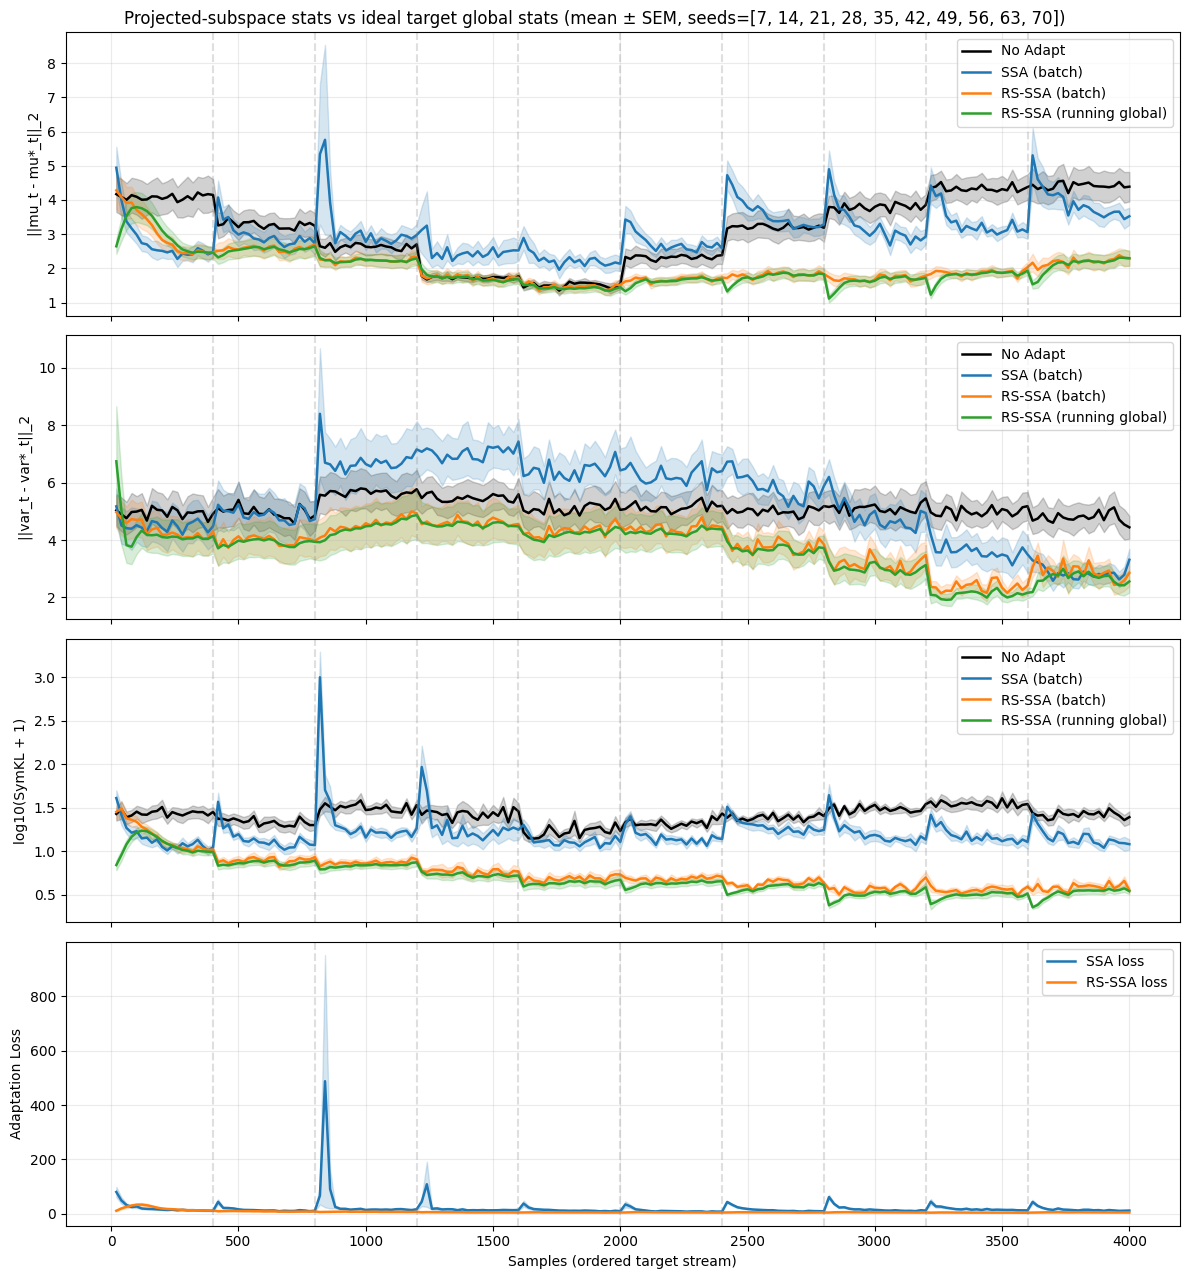

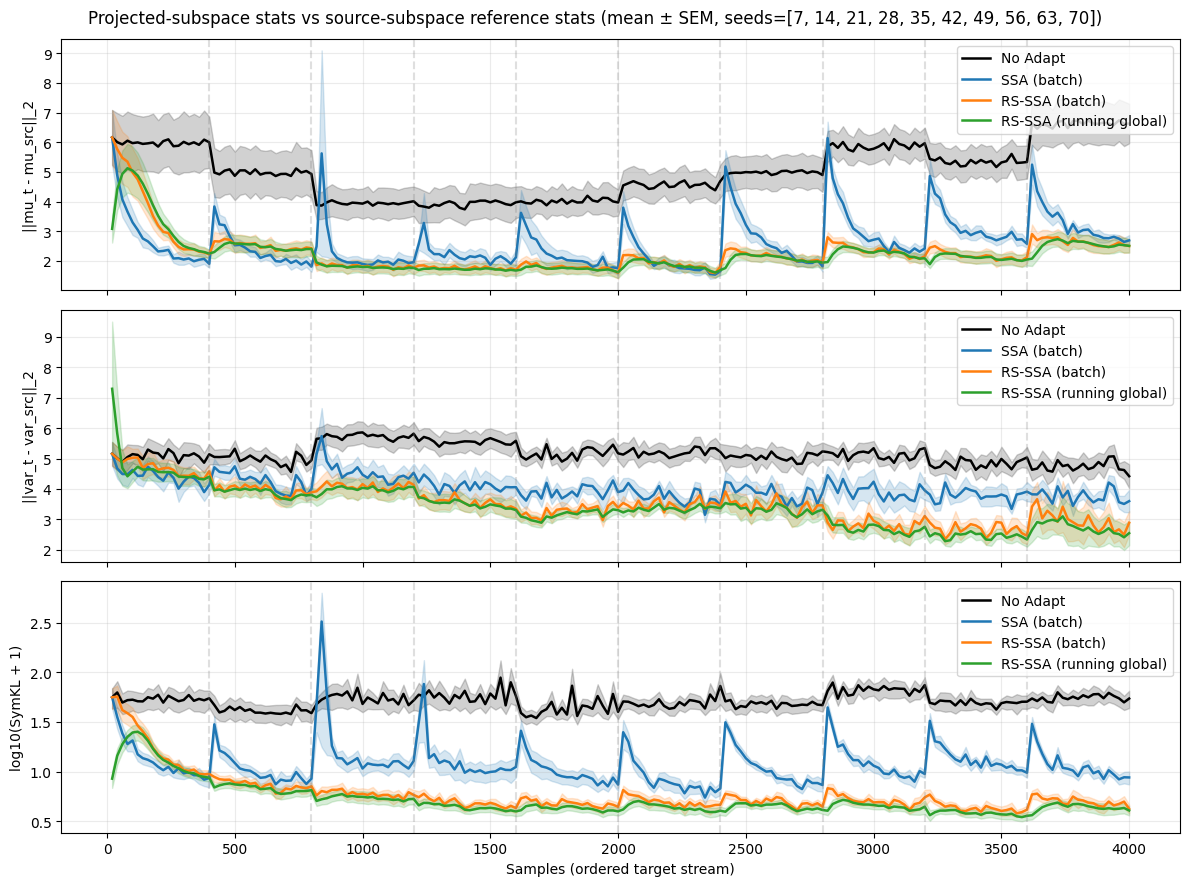

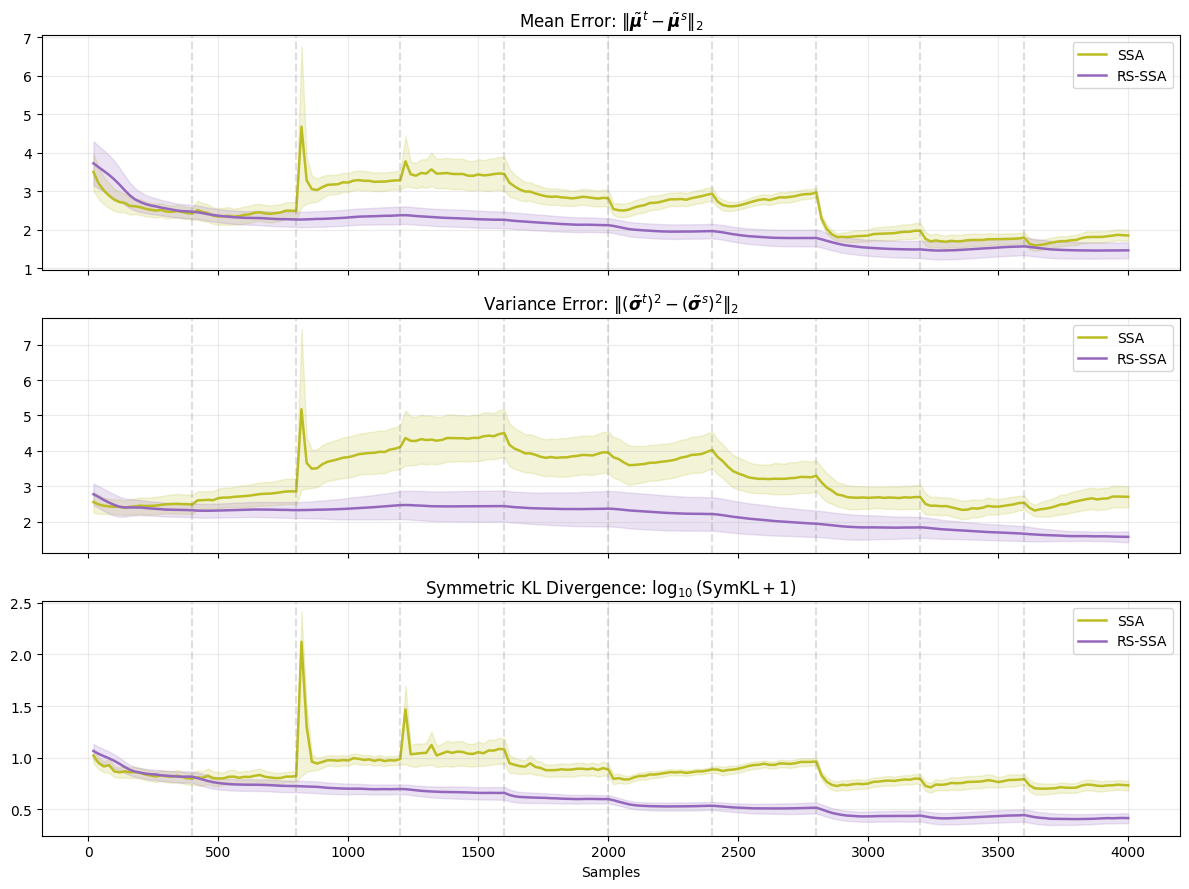

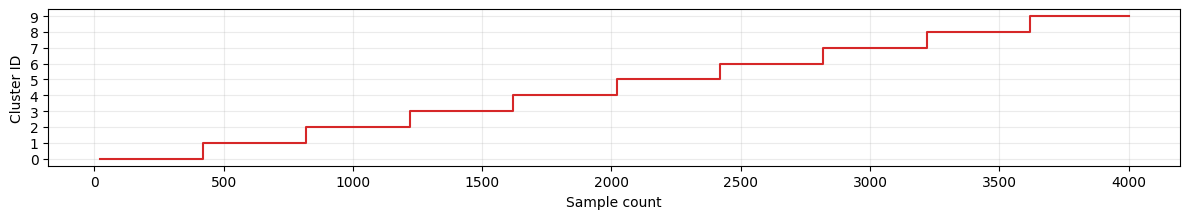

In [9]:
steps = np.arange(len(cluster_trace))
sample_counts = (steps + 1) * cfg["batch_size_stream"]
step_per_cluster = cfg["target_samples_per_cluster"] // cfg["batch_size_stream"]
boundaries = np.arange(step_per_cluster, len(steps), step_per_cluster)
boundary_samples = boundaries * cfg["batch_size_stream"]

import os
os.makedirs("fig", exist_ok=True)

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

plot_cfg = [
    ("no", "No Adapt", "black"),
    ("ssa_batch", "SSA (batch)", "tab:blue"),
    ("rs_batch", "RS-SSA (batch)", "tab:orange"),
    ("rs_global", "RS-SSA (running global)", "tab:green"),
]
plot_cfg_source = [
    ("no", "No Adapt", "black"),
    ("ssa_batch", "SSA (batch)", "tab:blue"),
    ("rs_batch", "RS-SSA (batch)", "tab:orange"),
    ("rs_global", "RS-SSA (running global)", "tab:green"),
]
plot_cfg_source_global = [
    ("ssa_target_global", "SSA", "tab:olive"),
    ("rs_target_global", "RS-SSA", "tab:purple"),
]

for key, label, color in plot_cfg:
    m_mean = agg_metrics[key]["mean_l2"]["mean"]
    m_sem = agg_metrics[key]["mean_l2"]["sem"]
    axes[0].plot(sample_counts, m_mean, label=label, color=color, linewidth=1.8)
    axes[0].fill_between(sample_counts, m_mean - m_sem, m_mean + m_sem, color=color, alpha=0.18)

    v_mean = agg_metrics[key]["var_l2"]["mean"]
    v_sem = agg_metrics[key]["var_l2"]["sem"]
    axes[1].plot(sample_counts, v_mean, label=label, color=color, linewidth=1.8)
    axes[1].fill_between(sample_counts, v_mean - v_sem, v_mean + v_sem, color=color, alpha=0.18)

    k_mean = agg_metrics[key]["sym_kl"]["mean"]
    k_sem = agg_metrics[key]["sym_kl"]["sem"]
    k_line = np.log10(k_mean + 1.0)
    k_low = np.log10(np.clip(k_mean - k_sem, a_min=0.0, a_max=None) + 1.0)
    k_high = np.log10(k_mean + k_sem + 1.0)
    axes[2].plot(sample_counts, k_line, label=label, color=color, linewidth=1.8)
    axes[2].fill_between(sample_counts, k_low, k_high, color=color, alpha=0.18)

for key, color, label in [("ssa", "tab:blue", "SSA loss"), ("rs", "tab:orange", "RS-SSA loss")]:
    l_mean = agg_losses[key]["mean"]
    l_sem = agg_losses[key]["sem"]
    axes[3].plot(sample_counts, l_mean, label=label, color=color, linewidth=1.8)
    axes[3].fill_between(sample_counts, l_mean - l_sem, l_mean + l_sem, color=color, alpha=0.18)

axes[0].set_ylabel("||mu_t - mu*_t||_2")
axes[1].set_ylabel("||var_t - var*_t||_2")
axes[2].set_ylabel("log10(SymKL + 1)")
axes[3].set_ylabel("Adaptation Loss")
axes[3].set_xlabel("Samples (ordered target stream)")

for ax in axes:
    for b in boundary_samples:
        ax.axvline(b, color="gray", linestyle="--", alpha=0.25)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

fig.suptitle(f"Projected-subspace stats vs ideal target global stats (mean ± SEM, seeds={seed_list})")
plt.tight_layout()
plt.show()

fig_src, axes_src = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for key, label, color in plot_cfg_source:
    m_mean = agg_metrics_source[key]["mean_l2"]["mean"]
    m_sem = agg_metrics_source[key]["mean_l2"]["sem"]
    axes_src[0].plot(sample_counts, m_mean, label=label, color=color, linewidth=1.8)
    axes_src[0].fill_between(sample_counts, m_mean - m_sem, m_mean + m_sem, color=color, alpha=0.18)

    v_mean = agg_metrics_source[key]["var_l2"]["mean"]
    v_sem = agg_metrics_source[key]["var_l2"]["sem"]
    axes_src[1].plot(sample_counts, v_mean, label=label, color=color, linewidth=1.8)
    axes_src[1].fill_between(sample_counts, v_mean - v_sem, v_mean + v_sem, color=color, alpha=0.18)

    k_mean = agg_metrics_source[key]["sym_kl"]["mean"]
    k_sem = agg_metrics_source[key]["sym_kl"]["sem"]
    k_line = np.log10(k_mean + 1.0)
    k_low = np.log10(np.clip(k_mean - k_sem, a_min=0.0, a_max=None) + 1.0)
    k_high = np.log10(k_mean + k_sem + 1.0)
    axes_src[2].plot(sample_counts, k_line, label=label, color=color, linewidth=1.8)
    axes_src[2].fill_between(sample_counts, k_low, k_high, color=color, alpha=0.18)

axes_src[0].set_ylabel("||mu_t - mu_src||_2")
axes_src[1].set_ylabel("||var_t - var_src||_2")
axes_src[2].set_ylabel("log10(SymKL + 1)")
axes_src[2].set_xlabel("Samples (ordered target stream)")

for ax in axes_src:
    for b in boundary_samples:
        ax.axvline(b, color="gray", linestyle="--", alpha=0.25)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

fig_src.suptitle(f"Projected-subspace stats vs source-subspace reference stats (mean ± SEM, seeds={seed_list})")
plt.tight_layout()
plt.show()

fig_src_global, axes_src_global = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for key, label, color in plot_cfg_source_global:
    m_mean = agg_metrics_source[key]["mean_l2"]["mean"]
    m_sem = agg_metrics_source[key]["mean_l2"]["sem"]
    axes_src_global[0].plot(sample_counts, m_mean, label=label, color=color, linewidth=1.8)
    axes_src_global[0].fill_between(sample_counts, m_mean - m_sem, m_mean + m_sem, color=color, alpha=0.18)

    v_mean = agg_metrics_source[key]["var_l2"]["mean"]
    v_sem = agg_metrics_source[key]["var_l2"]["sem"]
    axes_src_global[1].plot(sample_counts, v_mean, label=label, color=color, linewidth=1.8)
    axes_src_global[1].fill_between(sample_counts, v_mean - v_sem, v_mean + v_sem, color=color, alpha=0.18)

    k_mean = agg_metrics_source[key]["sym_kl"]["mean"]
    k_sem = agg_metrics_source[key]["sym_kl"]["sem"]
    k_line = np.log10(k_mean + 1.0)
    k_low = np.log10(np.clip(k_mean - k_sem, a_min=0.0, a_max=None) + 1.0)
    k_high = np.log10(k_mean + k_sem + 1.0)
    axes_src_global[2].plot(sample_counts, k_line, label=label, color=color, linewidth=1.8)
    axes_src_global[2].fill_between(sample_counts, k_low, k_high, color=color, alpha=0.18)

axes_src_global[0].set_title(r"Mean Error: $\|\tilde{\boldsymbol{\mu}}^{t} - \tilde{\boldsymbol{\mu}}^{s}\|_{2}$")
axes_src_global[1].set_title(r"Variance Error: $\| (\tilde{\boldsymbol{\sigma}}^{t})^{2} - (\tilde{\boldsymbol{\sigma}}^{s})^{2} \|_{2}$")
axes_src_global[2].set_title(
    r"Symmetric KL Divergence: $\log_{10}(\mathrm{SymKL} + 1) $"
)
axes_src_global[2].set_xlabel("Samples")

for ax in axes_src_global:
    for b in boundary_samples:
        ax.axvline(b, color="gray", linestyle="--", alpha=0.25)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

# fig_src_global.suptitle(f"SSA/RS-SSA global projected-subspace stats vs source-subspace reference stats (mean ± SEM, seeds={seed_list})")
plt.tight_layout()
fig_src_global.savefig(
    "fig/ssa_rs_ssa_global_projected_subspace_stats_vs_source_subspace_reference_stats.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

fig_stream = plt.figure(figsize=(12, 2.3))
plt.plot(sample_counts, cluster_trace, drawstyle="steps-post", color="tab:red")
plt.yticks(range(cfg["num_clusters"]))
plt.xlabel("Sample count")
plt.ylabel("Cluster ID")
# plt.title("Target stream order (cluster blocks, representative seed)")
plt.grid(alpha=0.25)
plt.tight_layout()
fig_stream.savefig(
    "fig/target_stream_order_cluster_blocks_representative_seed.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()


## 追加実験: シャッフルIDストリームでの RS-SSA 収束確認

- 目的: RS-SSAでターゲットのグローバル統計量がソース統計量へ収束するか確認
- 条件: クラスタIDが順番ではなく、シャッフル順で流れるターゲットストリーム
- 総サンプル数: 1000 / 2000 / 4000 / 8000 / 16000
- 各条件のseed: 5回
- ハイパーパラメータ: rs_alpha = [0.01, 0.1, 0.5, 1.0], rs_ema_momentum = [0.99, 0.999, 1.0]

In [4]:
sample_totals = [1000, 2000, 4000, 8000, 16000]
seed_list_shuffle = [7, 14, 21, 28, 35]


def build_seed_source_artifacts(seed: int, cfg: dict, device: torch.device) -> dict:
    """Train source model once per seed and cache reusable artifacts."""
    set_seed(seed)

    input_dim = cfg["input_dim"]
    hidden_dim = cfg["hidden_dim"]
    num_clusters = cfg["num_clusters"]

    centers = make_evenly_spaced_centers(
        num_clusters=num_clusters,
        input_dim=input_dim,
        spacing=cfg["cluster_center_spacing"],
    )

    x_src, y_src, _ = make_cluster_dataset(
        centers=centers,
        samples_per_cluster=cfg["source_samples_per_cluster"],
        cluster_std=cfg["cluster_std"],
        ordered=False,
    )

    add_shift_common = sample_vector_on_hypersphere(input_dim, cfg["add_shift_scale"])[None, :]
    mul_shift_common = (
        cfg["mul_shift_center"] + sample_vector_on_hypersphere(input_dim, cfg["mul_shift_scale"])
    )[None, :]
    add_shift = np.repeat(add_shift_common, num_clusters, axis=0)
    mul_shift = np.repeat(mul_shift_common, num_clusters, axis=0)

    source_model = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    train_source_model(
        source_model,
        x_src,
        y_src,
        epochs=cfg["source_epochs"],
        lr=cfg["source_lr"],
        batch_size=cfg["source_batch_size"],
    )

    x_src_t = torch.tensor(x_src, dtype=torch.float32, device=device)

    pca_dim = hidden_dim
    pca_feat_mean, pca_basis, source_pc_var = fit_pca_basis_from_source(source_model, x_src_t, top_k=pca_dim)
    source_mu_ref, source_var_ref = projected_stats(source_model, x_src_t, pca_feat_mean, pca_basis)

    with torch.no_grad():
        regressor_weight = source_model.fc2.weight
        dim_weight = torch.abs(regressor_weight @ pca_basis).sum(dim=0)
        dim_weight = (dim_weight + cfg["weight_bias"]).pow(cfg["weight_exp"])

    return {
        "seed": seed,
        "centers": centers,
        "add_shift": add_shift,
        "mul_shift": mul_shift,
        "source_state_dict": copy.deepcopy(source_model.state_dict()),
        "pca_feat_mean": pca_feat_mean.detach().clone(),
        "pca_basis": pca_basis.detach().clone(),
        "source_pc_var": source_pc_var.detach().clone(),
        "source_mu_ref": source_mu_ref.detach().clone(),
        "source_var_ref": source_var_ref.detach().clone(),
        "dim_weight": dim_weight.detach().clone(),
    }


def run_rs_validation_with_artifacts(
    seed_artifacts: dict,
    cfg: dict,
    device: torch.device,
    stream_shuffle: bool = True,
) -> dict:
    seed = int(seed_artifacts["seed"])

    # Keep stream generation and stochastic behavior fixed per (seed, sample_size)
    run_seed = seed * 1_000_003 + cfg["target_samples_per_cluster"] * 97
    set_seed(run_seed)

    input_dim = cfg["input_dim"]
    hidden_dim = cfg["hidden_dim"]

    x_tgt, y_tgt, c_tgt = make_cluster_dataset(
        centers=seed_artifacts["centers"],
        samples_per_cluster=cfg["target_samples_per_cluster"],
        cluster_std=cfg["cluster_std"],
        ordered=False,
        add_shift=seed_artifacts["add_shift"],
        mul_shift=seed_artifacts["mul_shift"],
    )

    x_tgt_t = torch.tensor(x_tgt, dtype=torch.float32, device=device)

    pca_feat_mean = seed_artifacts["pca_feat_mean"]
    pca_basis = seed_artifacts["pca_basis"]
    source_pc_var = seed_artifacts["source_pc_var"]
    source_mu_ref = seed_artifacts["source_mu_ref"]
    source_var_ref = seed_artifacts["source_var_ref"]
    dim_weight = seed_artifacts["dim_weight"]

    model_rs_eval = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    model_rs_eval.load_state_dict(copy.deepcopy(seed_artifacts["source_state_dict"]))

    model_rs_source = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    model_rs_source.load_state_dict(copy.deepcopy(seed_artifacts["source_state_dict"]))
    model_rs_source.eval()
    model_rs_source.requires_grad_(False)

    opt_rs = torch.optim.SGD([model_rs_eval.fc1.weight], lr=cfg["adapt_lr"])
    rs_state = RSSSAState(
        alpha=cfg["rs_alpha"],
        buffer_size=cfg["buffer_size"],
        min_buffer_size=cfg["min_buffer_size"],
        global_mu_pc=source_mu_ref.detach().clone(),
        global_var_pc=source_var_ref.detach().clone(),
        pc_initialized=True,
    )
    use_cuda = device.type == "cuda"

    stream_ds = TensorDataset(
        torch.tensor(x_tgt, dtype=torch.float32),
        torch.tensor(y_tgt, dtype=torch.float32),
        torch.tensor(c_tgt, dtype=torch.long),
    )
    stream_loader = DataLoader(
        stream_ds,
        batch_size=cfg["batch_size_stream"],
        shuffle=stream_shuffle,
        num_workers=16 if use_cuda else 0,
        pin_memory=use_cuda,
        persistent_workers=use_cuda,
    )

    metrics = {
        "cluster": [],
        "vs_source": {
            "rs_target_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        },
        "loss": {"rs": []},
    }

    for xb, _, cb in stream_loader:
        xb = xb.to(device, non_blocking=use_cuda)

        rs_loss, _, _, _, _ = adapt_step_rs_ssa(
            model_rs_eval,
            opt_rs,
            model_rs_source,
            rs_state,
            xb,
            pca_feat_mean,
            pca_basis,
            source_pc_var,
            dim_weight,
            cfg["rs_ema_momentum"],
        )

        mu_global_rs, var_global_rs = projected_stats(model_rs_eval, x_tgt_t, pca_feat_mean, pca_basis)
        cmp_rs_target_global_src = compare_stats(mu_global_rs, var_global_rs, source_mu_ref, source_var_ref)
        for k, v in cmp_rs_target_global_src.items():
            metrics["vs_source"]["rs_target_global"][k].append(v)

        metrics["cluster"].extend(cb.cpu().numpy().tolist())
        metrics["loss"]["rs"].append(rs_loss)

    out = {
        "seed": seed,
        "metrics": metrics,
        "cluster": np.array(metrics["cluster"], dtype=np.int64),
        "buffer_size": 0 if rs_state.buffer_x is None else int(rs_state.buffer_x.size(0)),
    }
    return out


def mean_sem(values: list[float]) -> tuple[float, float]:
    arr = np.array(values, dtype=np.float64)
    mean = float(arr.mean())
    sem = float(arr.std(ddof=1) / np.sqrt(arr.size)) if arr.size > 1 else 0.0
    return mean, sem


if any(total % cfg["num_clusters"] != 0 for total in sample_totals):
    raise ValueError("Each sample total must be divisible by cfg['num_clusters']")

rs_alpha_list = [0.01, 0.1, 0.5, 1.0]
rs_ema_momentum_list = [0.99, 0.999, 1.0]
rs_param_grid = [(a, m) for a in rs_alpha_list for m in rs_ema_momentum_list]


seed_source_artifacts = {}
for seed in seed_list_shuffle:
    print(f"\n=== Prepare source model | seed={seed} ===")
    seed_source_artifacts[seed] = build_seed_source_artifacts(seed=seed, cfg=cfg, device=device)


sweep_results = {}
for rs_alpha, rs_ema_momentum in rs_param_grid:
    print(f"\n=== Hyperparam: rs_alpha={rs_alpha}, rs_ema_momentum={rs_ema_momentum} ===")
    combo_results = {}
    for total_samples in sample_totals:
        cfg_case = copy.deepcopy(cfg)
        cfg_case["target_samples_per_cluster"] = total_samples // cfg_case["num_clusters"]
        cfg_case["rs_alpha"] = rs_alpha
        cfg_case["rs_ema_momentum"] = rs_ema_momentum

        print(f"  - total_samples={total_samples}")
        case_results = []
        for seed in seed_list_shuffle:
            print(f"    * seed {seed}")
            res = run_rs_validation_with_artifacts(
                seed_artifacts=seed_source_artifacts[seed],
                cfg=cfg_case,
                device=device,
                stream_shuffle=True,
            )
            case_results.append(res)

        first_sym_kl = [r["metrics"]["vs_source"]["rs_target_global"]["sym_kl"][0] for r in case_results]
        final_mean_l2 = [r["metrics"]["vs_source"]["rs_target_global"]["mean_l2"][-1] for r in case_results]
        final_var_l2 = [r["metrics"]["vs_source"]["rs_target_global"]["var_l2"][-1] for r in case_results]
        final_sym_kl = [r["metrics"]["vs_source"]["rs_target_global"]["sym_kl"][-1] for r in case_results]
        sym_kl_ratio = [
            final / max(initial, 1e-12)
            for initial, final in zip(first_sym_kl, final_sym_kl)
        ]

        combo_results[total_samples] = {
            "results": case_results,
            "summary": {
                "first_sym_kl": mean_sem(first_sym_kl),
                "final_mean_l2": mean_sem(final_mean_l2),
                "final_var_l2": mean_sem(final_var_l2),
                "final_sym_kl": mean_sem(final_sym_kl),
                "sym_kl_ratio": mean_sem(sym_kl_ratio),
            },
        }

    sweep_results[(rs_alpha, rs_ema_momentum)] = combo_results




rs_sweep_artifacts = {
    "sweep_results": sweep_results,
    "sample_totals": sample_totals,
    "rs_param_grid": rs_param_grid,
    "num_clusters": cfg["num_clusters"],
}
print("RS-SSA sweep computation finished. Run the next plot cell to visualize.")



=== Prepare source model | seed=7 ===
[source train] epoch=  1 mse=26.1727
[source train] epoch= 50 mse=1.1897
[source train] epoch=100 mse=1.0253
[source train] epoch=150 mse=0.9921

=== Prepare source model | seed=14 ===
[source train] epoch=  1 mse=23.6026
[source train] epoch= 50 mse=1.0865
[source train] epoch=100 mse=0.8877
[source train] epoch=150 mse=0.8529

=== Prepare source model | seed=21 ===
[source train] epoch=  1 mse=26.2837
[source train] epoch= 50 mse=1.2151
[source train] epoch=100 mse=0.8935
[source train] epoch=150 mse=0.8183

=== Prepare source model | seed=28 ===
[source train] epoch=  1 mse=27.4345
[source train] epoch= 50 mse=1.2466
[source train] epoch=100 mse=0.9130
[source train] epoch=150 mse=0.7807

=== Prepare source model | seed=35 ===
[source train] epoch=  1 mse=27.0001
[source train] epoch= 50 mse=1.2025
[source train] epoch=100 mse=0.9117
[source train] epoch=150 mse=0.8081

=== Hyperparam: rs_alpha=0.01, rs_ema_momentum=0.99 ===
  - total_samples=1

    * seed 28
    * seed 35
  - total_samples=4000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=8000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=16000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35

=== Hyperparam: rs_alpha=0.1, rs_ema_momentum=1.0 ===
  - total_samples=1000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=2000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=4000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=8000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=16000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35

=== Hyperparam: rs_alpha=0.5, rs_ema_momentum=0.99 ===
  - total_samples=1000
    * seed 7
    * seed 14
    * seed 21
    * seed 28
    * seed 35
  - total_samples=2000
    * se

### RS-SSA Shuffled Sweep Plot Only
`rs_sweep_artifacts` が計算済みなら、このセル以降だけ再実行すればプロットを更新できます


=== RS-SSA target-global vs source (shuffled stream, 5 seeds) ===

--- rs_alpha=0.01, rs_ema_momentum=0.99 ---
samples | first_sym_kl      | final_mean_l2     | final_var_l2      | final_sym_kl      | final/first
   1000 |   8.6152 ±  1.5404 |   3.2721 ±  0.4505 |   2.5558 ±  0.5658 |   8.2810 ±  1.5200 |   0.9566 ±  0.0078
   2000 |   8.6419 ±  1.4913 |   3.2369 ±  0.4460 |   2.5606 ±  0.5710 |   7.9494 ±  1.4463 |   0.9120 ±  0.0140
   4000 |   8.5848 ±  1.5033 |   3.1657 ±  0.4427 |   2.4931 ±  0.5286 |   7.4424 ±  1.4334 |   0.8531 ±  0.0210
   8000 |   8.6446 ±  1.5029 |   3.1245 ±  0.4357 |   2.4474 ±  0.5084 |   7.1626 ±  1.4098 |   0.8111 ±  0.0271
  16000 |   8.6056 ±  1.5249 |   3.1020 ±  0.4331 |   2.4537 ±  0.5103 |   7.0075 ±  1.3988 |   0.7967 ±  0.0264

--- rs_alpha=0.01, rs_ema_momentum=0.999 ---
samples | first_sym_kl      | final_mean_l2     | final_var_l2      | final_sym_kl      | final/first
   1000 |   8.6152 ±  1.5404 |   3.2634 ±  0.4492 |   2.5513 ±  0.5645 | 

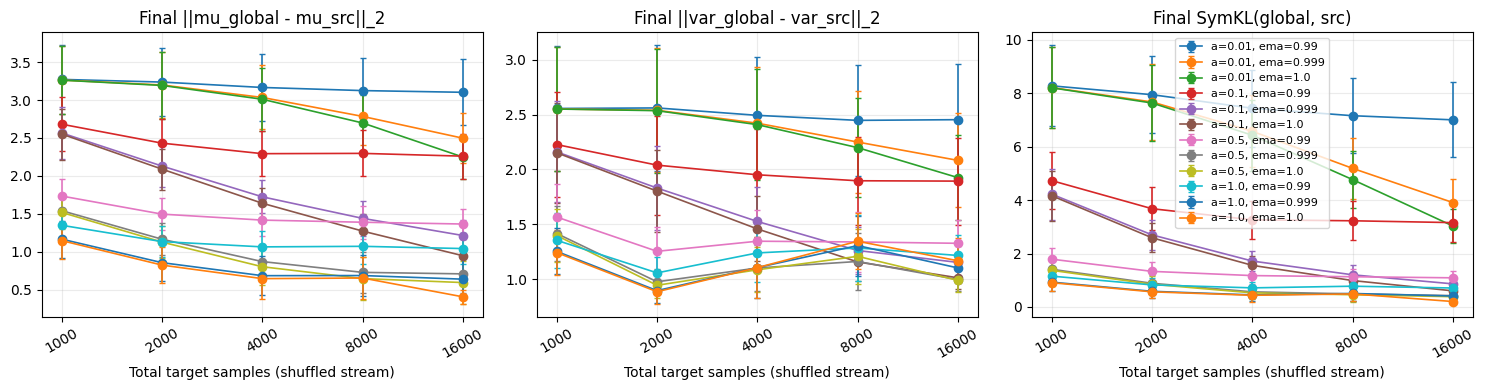

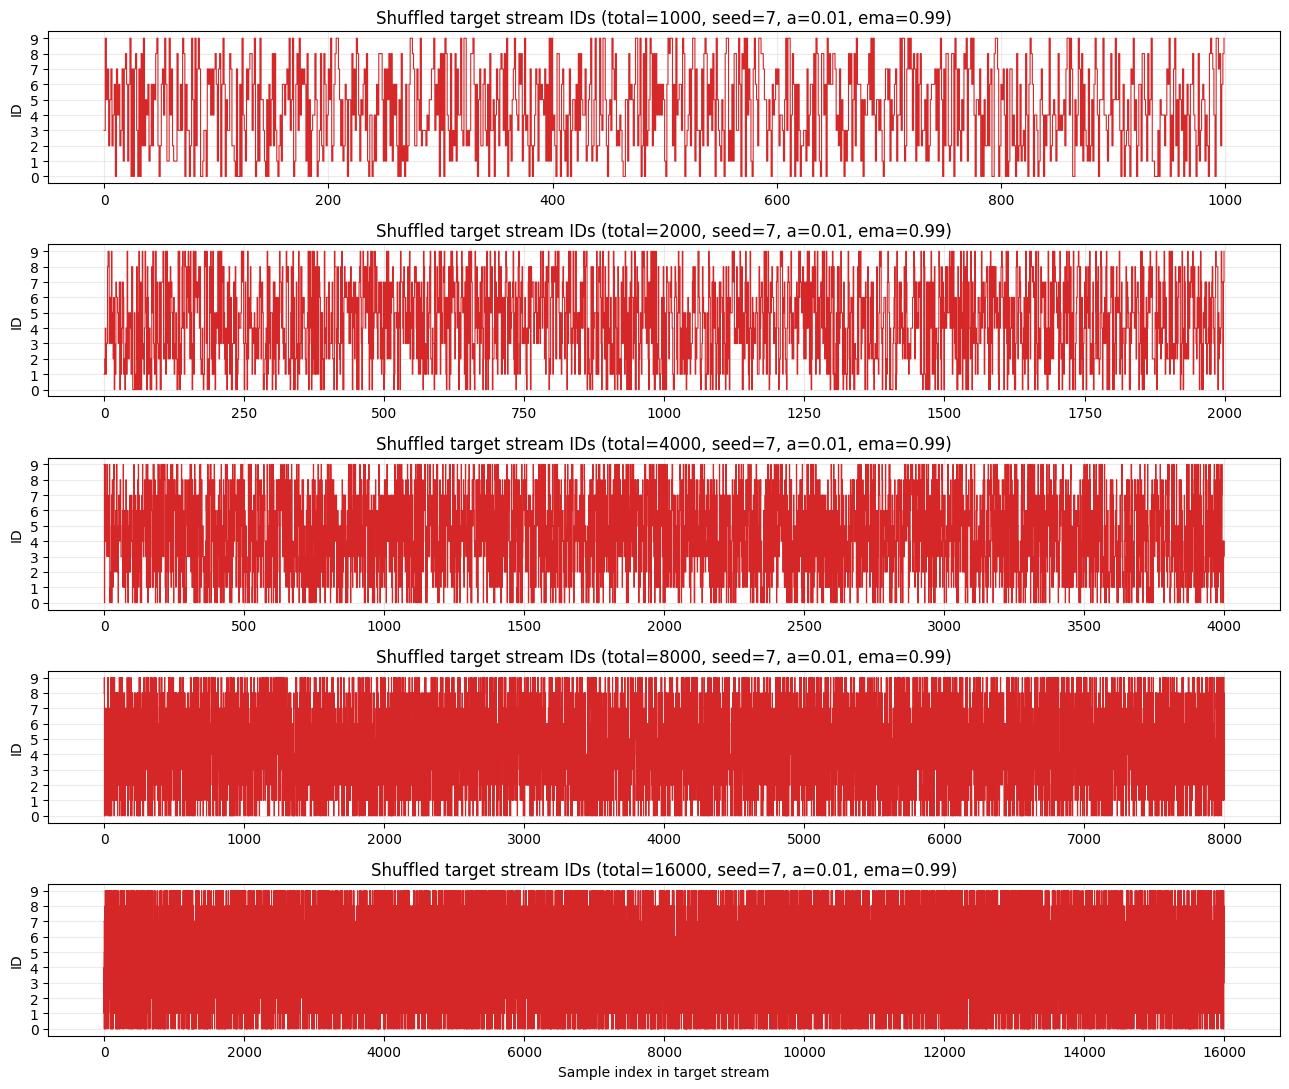

In [5]:
if "rs_sweep_artifacts" not in globals():
    raise RuntimeError("Run the RS-SSA shuffled sweep computation cell first.")

sweep_results = rs_sweep_artifacts["sweep_results"]
sample_totals = rs_sweep_artifacts["sample_totals"]
rs_param_grid = rs_sweep_artifacts["rs_param_grid"]
num_clusters = rs_sweep_artifacts["num_clusters"]

print("\n=== RS-SSA target-global vs source (shuffled stream, 5 seeds) ===")
for rs_alpha, rs_ema_momentum in rs_param_grid:
    print(f"\n--- rs_alpha={rs_alpha}, rs_ema_momentum={rs_ema_momentum} ---")
    print("samples | first_sym_kl      | final_mean_l2     | final_var_l2      | final_sym_kl      | final/first")
    for total_samples in sample_totals:
        s = sweep_results[(rs_alpha, rs_ema_momentum)][total_samples]["summary"]
        f0_m, f0_s = s["first_sym_kl"]
        m_m, m_s = s["final_mean_l2"]
        v_m, v_s = s["final_var_l2"]
        k_m, k_s = s["final_sym_kl"]
        r_m, r_s = s["sym_kl_ratio"]
        print(
            f"{total_samples:7d} | {f0_m:8.4f} ± {f0_s:7.4f} | {m_m:8.4f} ± {m_s:7.4f} | {v_m:8.4f} ± {v_s:7.4f} | {k_m:8.4f} ± {k_s:7.4f} | {r_m:8.4f} ± {r_s:7.4f}"
        )


fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
metric_specs = [
    ("final_mean_l2", "Final ||mu_global - mu_src||_2"),
    ("final_var_l2", "Final ||var_global - var_src||_2"),
    ("final_sym_kl", "Final SymKL(global, src)"),
]

for ax, (metric_key, title) in zip(axes, metric_specs):
    for rs_alpha, rs_ema_momentum in rs_param_grid:
        y = [sweep_results[(rs_alpha, rs_ema_momentum)][t]["summary"][metric_key][0] for t in sample_totals]
        yerr = [sweep_results[(rs_alpha, rs_ema_momentum)][t]["summary"][metric_key][1] for t in sample_totals]
        label = f"a={rs_alpha}, ema={rs_ema_momentum}"
        ax.errorbar(sample_totals, y, yerr=yerr, marker="o", capsize=2, linewidth=1.2, label=label)
    ax.set_xscale("log", base=2)
    ax.set_xticks(sample_totals)
    ax.set_xticklabels([str(t) for t in sample_totals], rotation=30)
    ax.set_title(title)
    ax.set_xlabel("Total target samples (shuffled stream)")
    ax.grid(alpha=0.25)

axes[-1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


rep_alpha, rep_ema_momentum = rs_param_grid[0]
rep_combo_results = sweep_results[(rep_alpha, rep_ema_momentum)]
fig_stream, axes_stream = plt.subplots(len(sample_totals), 1, figsize=(13, 2.2 * len(sample_totals)), sharex=False)
if len(sample_totals) == 1:
    axes_stream = [axes_stream]

for ax, total_samples in zip(axes_stream, sample_totals):
    rep = rep_combo_results[total_samples]["results"][0]
    cluster_trace = rep["cluster"]
    steps = np.arange(cluster_trace.shape[0])
    ax.plot(steps, cluster_trace, drawstyle="steps-post", linewidth=0.8, color="tab:red")
    ax.set_ylabel("ID")
    ax.set_yticks(range(num_clusters))
    ax.set_title(
        f"Shuffled target stream IDs (total={total_samples}, seed={rep['seed']}, a={rep_alpha}, ema={rep_ema_momentum})"
    )
    ax.grid(alpha=0.25)

axes_stream[-1].set_xlabel("Sample index in target stream")
plt.tight_layout()
plt.show()


## 追加実験: SSA と RS-SSA の収束比較

- seedごとに準備済みのsourceモデルを固定して、SSA/RS-SSAの収束を比較
- 指標: target global stats vs source stats の `mean_l2 / var_l2 / sym_kl`
- 表示: サンプルサイズごとの最終値(平均±SEM)と、step方向の収束曲線

In [ ]:
compare_sample_totals = [1000, 2000, 4000, 8000, 16000, 32000]
compare_seed_list = seed_list_shuffle

# You can change these two to compare different RS settings.
compare_rs_alpha = 0.5
compare_rs_ema_momentum = 0.99


def run_ssa_rs_comparison_with_artifacts(
    seed_artifacts: dict,
    cfg: dict,
    device: torch.device,
    stream_shuffle: bool = True,
) -> dict:
    seed = int(seed_artifacts["seed"])

    # Keep target stream reproducible for (seed, sample_size).
    run_seed = seed * 1_000_003 + cfg["target_samples_per_cluster"] * 97
    set_seed(run_seed)

    input_dim = cfg["input_dim"]
    hidden_dim = cfg["hidden_dim"]

    x_tgt, y_tgt, c_tgt = make_cluster_dataset(
        centers=seed_artifacts["centers"],
        samples_per_cluster=cfg["target_samples_per_cluster"],
        cluster_std=cfg["cluster_std"],
        ordered=False,
        add_shift=seed_artifacts["add_shift"],
        mul_shift=seed_artifacts["mul_shift"],
    )

    x_tgt_t = torch.tensor(x_tgt, dtype=torch.float32, device=device)

    pca_feat_mean = seed_artifacts["pca_feat_mean"]
    pca_basis = seed_artifacts["pca_basis"]
    source_pc_var = seed_artifacts["source_pc_var"]
    source_mu_ref = seed_artifacts["source_mu_ref"]
    source_var_ref = seed_artifacts["source_var_ref"]
    dim_weight = seed_artifacts["dim_weight"]

    model_ssa = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    model_ssa.load_state_dict(copy.deepcopy(seed_artifacts["source_state_dict"]))

    model_rs = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    model_rs.load_state_dict(copy.deepcopy(seed_artifacts["source_state_dict"]))

    model_rs_source = ShallowRegressor(input_dim, hidden_dim, 1).to(device)
    model_rs_source.load_state_dict(copy.deepcopy(seed_artifacts["source_state_dict"]))
    model_rs_source.eval()
    model_rs_source.requires_grad_(False)

    opt_ssa = torch.optim.SGD([model_ssa.fc1.weight], lr=cfg["adapt_lr"])
    opt_rs = torch.optim.SGD([model_rs.fc1.weight], lr=cfg["adapt_lr"])

    rs_state = RSSSAState(
        alpha=cfg["rs_alpha"],
        buffer_size=cfg["buffer_size"],
        min_buffer_size=cfg["min_buffer_size"],
        global_mu_pc=source_mu_ref.detach().clone(),
        global_var_pc=source_var_ref.detach().clone(),
        pc_initialized=True,
    )

    use_cuda = device.type == "cuda"
    stream_ds = TensorDataset(
        torch.tensor(x_tgt, dtype=torch.float32),
        torch.tensor(y_tgt, dtype=torch.float32),
        torch.tensor(c_tgt, dtype=torch.long),
    )
    stream_loader = DataLoader(
        stream_ds,
        batch_size=cfg["batch_size_stream"],
        shuffle=stream_shuffle,
        num_workers=16 if use_cuda else 0,
        pin_memory=use_cuda,
        persistent_workers=use_cuda,
    )

    metrics = {
        "cluster": [],
        "ssa_target_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "rs_target_global": {"mean_l2": [], "var_l2": [], "sym_kl": []},
        "loss": {"ssa": [], "rs": []},
    }

    for xb, _, cb in stream_loader:
        xb = xb.to(device, non_blocking=use_cuda)

        ssa_loss, _, _ = adapt_step_ssa(
            model_ssa,
            opt_ssa,
            xb,
            pca_feat_mean,
            pca_basis,
            source_pc_var,
            dim_weight,
        )

        rs_loss, _, _, _, _ = adapt_step_rs_ssa(
            model_rs,
            opt_rs,
            model_rs_source,
            rs_state,
            xb,
            pca_feat_mean,
            pca_basis,
            source_pc_var,
            dim_weight,
            cfg["rs_ema_momentum"],
        )

        mu_global_ssa, var_global_ssa = projected_stats(model_ssa, x_tgt_t, pca_feat_mean, pca_basis)
        mu_global_rs, var_global_rs = projected_stats(model_rs, x_tgt_t, pca_feat_mean, pca_basis)

        cmp_ssa = compare_stats(mu_global_ssa, var_global_ssa, source_mu_ref, source_var_ref)
        cmp_rs = compare_stats(mu_global_rs, var_global_rs, source_mu_ref, source_var_ref)

        for k, v in cmp_ssa.items():
            metrics["ssa_target_global"][k].append(v)
        for k, v in cmp_rs.items():
            metrics["rs_target_global"][k].append(v)

        metrics["cluster"].extend(cb.cpu().numpy().tolist())
        metrics["loss"]["ssa"].append(ssa_loss)
        metrics["loss"]["rs"].append(rs_loss)

    return {
        "seed": seed,
        "metrics": metrics,
        "cluster": np.array(metrics["cluster"], dtype=np.int64),
        "buffer_size": 0 if rs_state.buffer_x is None else int(rs_state.buffer_x.size(0)),
    }


# Reuse prepared source models per seed. Build only if not already present.
if "seed_source_artifacts" not in globals():
    seed_source_artifacts = {}
    for seed in compare_seed_list:
        print(f"\n=== Prepare source model | seed={seed} ===")
        seed_source_artifacts[seed] = build_seed_source_artifacts(seed=seed, cfg=cfg, device=device)


compare_cfg_base = copy.deepcopy(cfg)
compare_cfg_base["rs_alpha"] = compare_rs_alpha
compare_cfg_base["rs_ema_momentum"] = compare_rs_ema_momentum

ssa_rs_compare = {}
for total_samples in compare_sample_totals:
    cfg_case = copy.deepcopy(compare_cfg_base)
    cfg_case["target_samples_per_cluster"] = total_samples // cfg_case["num_clusters"]

    print(f"\n=== SSA vs RS | total_samples={total_samples}, rs_alpha={compare_rs_alpha}, rs_ema={compare_rs_ema_momentum} ===")
    case_results = []
    for seed in compare_seed_list:
        print(f"  - seed {seed}")
        res = run_ssa_rs_comparison_with_artifacts(
            seed_artifacts=seed_source_artifacts[seed], # type: ignore
            cfg=cfg_case,
            device=device,
            stream_shuffle=True,
        )
        case_results.append(res)

    agg = {}
    for method in ["ssa_target_global", "rs_target_global"]:
        agg[method] = {}
        for metric in ["mean_l2", "var_l2", "sym_kl"]:
            arr = np.stack([np.array(r["metrics"][method][metric], dtype=np.float64) for r in case_results], axis=0)
            agg[method][metric] = {
                "mean": arr.mean(axis=0),
                "sem": sem_from_samples(arr),
                "all": arr,
            }

    ssa_rs_compare[total_samples] = {
        "results": case_results,
        "agg": agg,
    }




ssa_rs_compare_artifacts = {
    "ssa_rs_compare": ssa_rs_compare,
    "compare_sample_totals": compare_sample_totals,
    "compare_rs_alpha": compare_rs_alpha,
    "compare_rs_ema_momentum": compare_rs_ema_momentum,
}
print("SSA vs RS-SSA computation finished. Run the next plot cell to visualize.")



=== SSA vs RS | total_samples=1000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35

=== SSA vs RS | total_samples=2000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35

=== SSA vs RS | total_samples=4000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35

=== SSA vs RS | total_samples=8000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35

=== SSA vs RS | total_samples=16000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35

=== SSA vs RS | total_samples=32000, rs_alpha=0.5, rs_ema=0.99 ===
  - seed 7
  - seed 14
  - seed 21
  - seed 28
  - seed 35
SSA vs RS-SSA computation finished. Run the next plot cell to visualize.


### SSA vs RS-SSA Plot Only
`ssa_rs_compare_artifacts` が計算済みなら、このセルだけ再実行してプロットを微修正できます


=== Final Step Comparison: SSA vs RS-SSA (mean ± SEM across seeds) ===
samples | ssa_final_sym_kl   | rs_final_sym_kl    | rs/ssa
   1000 |   0.8706 ±  0.2670 |   1.8128 ±  0.4235 |   2.3942 ±  0.4616
   2000 |   0.5616 ±  0.2519 |   1.3632 ±  0.3910 |   3.4757 ±  1.1553
   4000 |   0.4561 ±  0.2762 |   1.1985 ±  0.3430 |   4.7965 ±  1.4240
   8000 |   0.3977 ±  0.2562 |   1.1390 ±  0.3078 |   6.3691 ±  2.4895
  16000 |   0.1222 ±  0.0309 |   1.1146 ±  0.2870 |   9.9559 ±  2.4949
  32000 |   0.1099 ±  0.0169 |   1.1706 ±  0.3640 |  10.9461 ±  2.9952


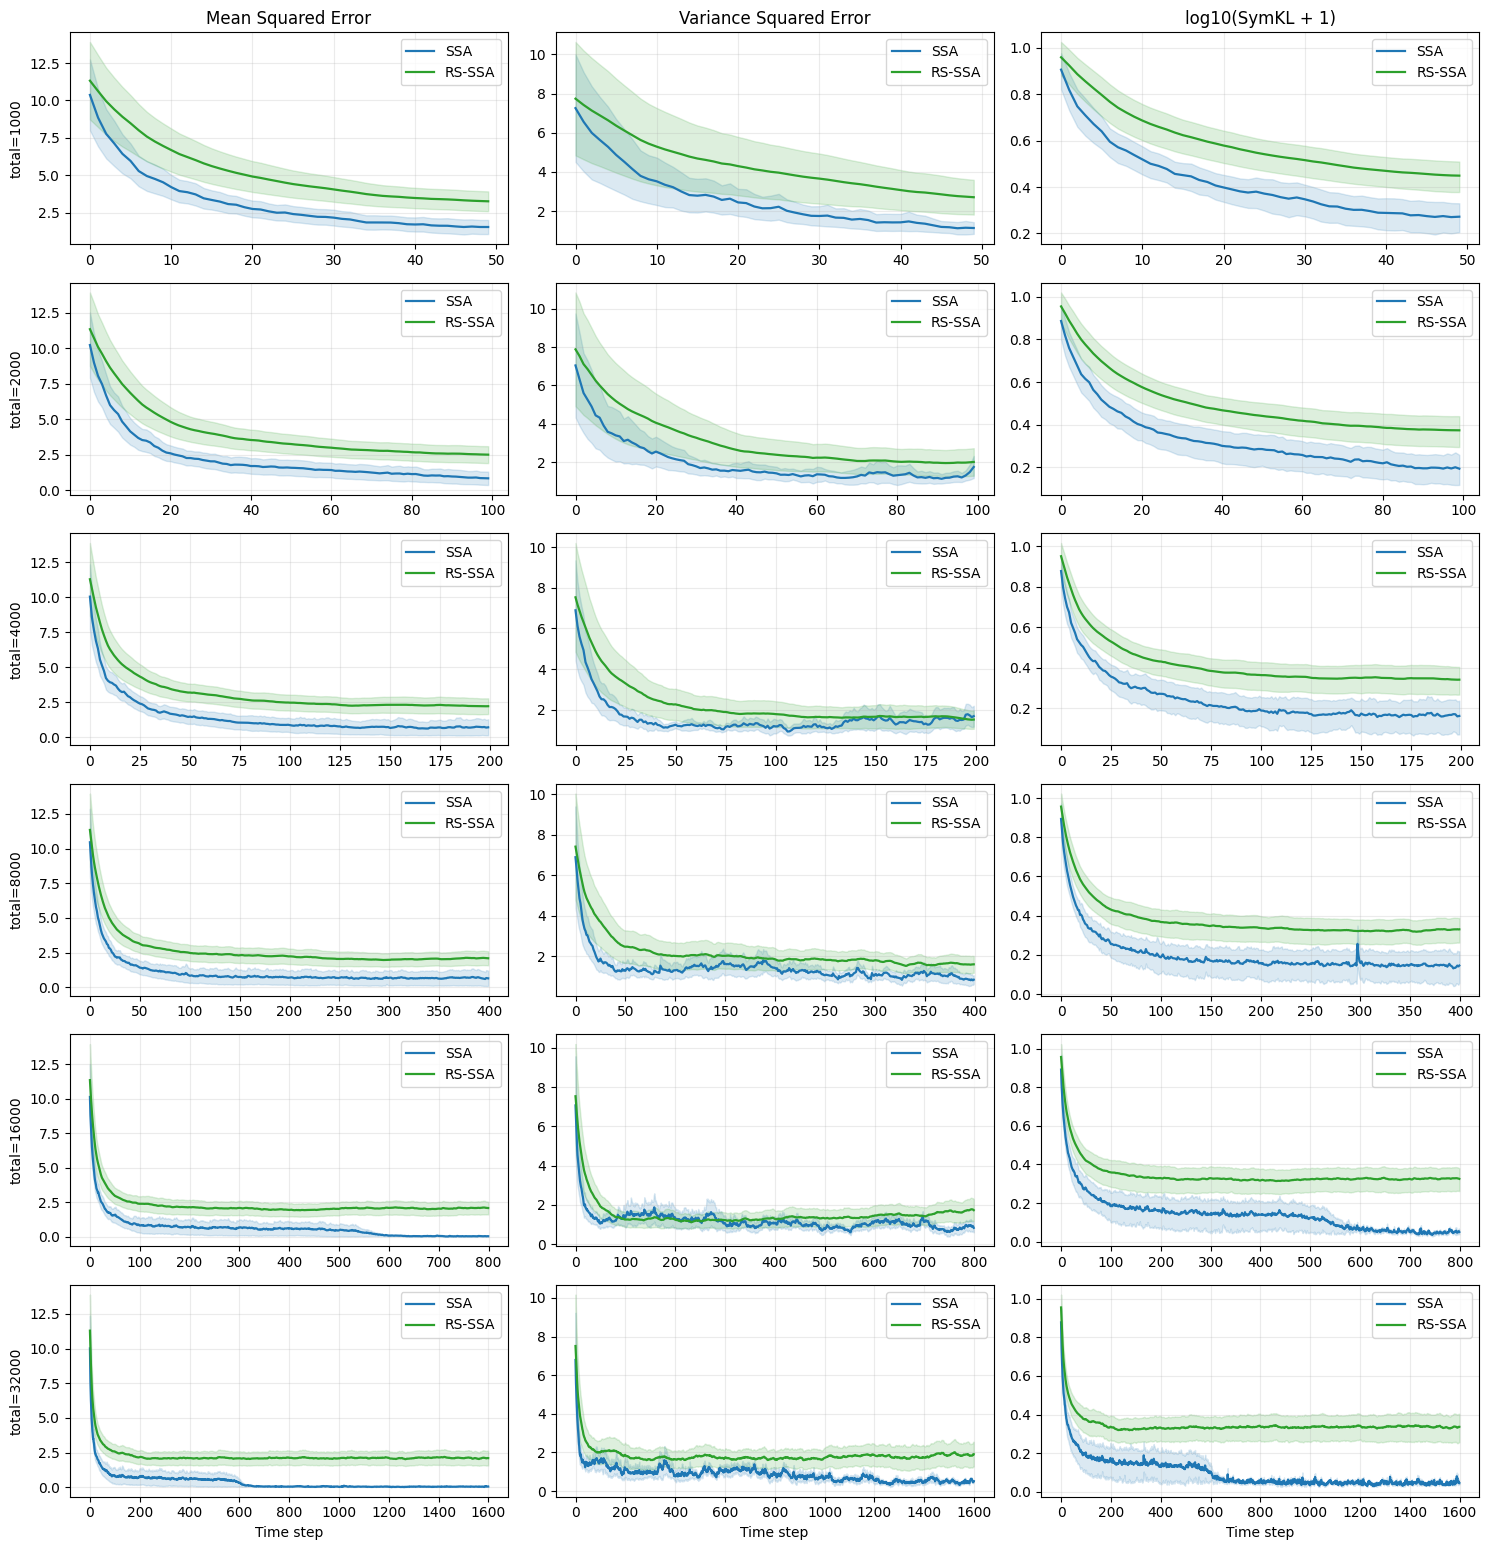

In [7]:
if "ssa_rs_compare_artifacts" not in globals():
    raise RuntimeError("Run the SSA vs RS-SSA computation cell first.")

ssa_rs_compare = ssa_rs_compare_artifacts["ssa_rs_compare"]
compare_sample_totals = ssa_rs_compare_artifacts["compare_sample_totals"]
compare_rs_alpha = ssa_rs_compare_artifacts["compare_rs_alpha"]
compare_rs_ema_momentum = ssa_rs_compare_artifacts["compare_rs_ema_momentum"]

print("\n=== Final Step Comparison: SSA vs RS-SSA (mean ± SEM across seeds) ===")
print("samples | ssa_final_sym_kl   | rs_final_sym_kl    | rs/ssa")
for total_samples in compare_sample_totals:
    case = ssa_rs_compare[total_samples]
    ssa_final = np.array([r["metrics"]["ssa_target_global"]["sym_kl"][-1] for r in case["results"]], dtype=np.float64)
    rs_final = np.array([r["metrics"]["rs_target_global"]["sym_kl"][-1] for r in case["results"]], dtype=np.float64)

    ssa_m, ssa_s = mean_sem(ssa_final.tolist())
    rs_m, rs_s = mean_sem(rs_final.tolist())
    ratio = rs_final / np.maximum(ssa_final, 1e-12)
    r_m, r_s = mean_sem(ratio.tolist())

    print(
        f"{total_samples:7d} | {ssa_m:8.4f} ± {ssa_s:7.4f} | {rs_m:8.4f} ± {rs_s:7.4f} | {r_m:8.4f} ± {r_s:7.4f}"
    )


# Convergence curves for each sample size: mean/var squared error and SymKL.
metric_plot_specs = [
    ("mean_l2", "Mean Squared Error", True),
    ("var_l2", "Variance Squared Error", True),
    ("sym_kl", "log10(SymKL + 1)", False),
]

fig, axes = plt.subplots(
    len(compare_sample_totals),
    len(metric_plot_specs),
    figsize=(15, 2.6 * len(compare_sample_totals)),
    sharex=False,
)
if len(compare_sample_totals) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, total_samples in enumerate(compare_sample_totals):
    case = ssa_rs_compare[total_samples]

    for col, (metric_key, ylabel, square_before_agg) in enumerate(metric_plot_specs):
        ax = axes[row, col]

        for method, label, color in [
            ("ssa_target_global", "SSA", "tab:blue"),
            ("rs_target_global", "RS-SSA", "tab:green"),
        ]:
            arr = case["agg"][method][metric_key]["all"]
            if square_before_agg:
                arr = arr ** 2

            m = arr.mean(axis=0)
            s = sem_from_samples(arr)
            steps = np.arange(m.shape[0])

            if metric_key == "sym_kl":
                y = np.log10(m + 1.0)
                y_low = np.log10(np.clip(m - s, a_min=0.0, a_max=None) + 1.0)
                y_high = np.log10(m + s + 1.0)
            else:
                y = m
                y_low = np.clip(m - s, a_min=0.0, a_max=None)
                y_high = m + s

            ax.plot(steps, y, label=label, color=color, linewidth=1.6)
            ax.fill_between(steps, y_low, y_high, color=color, alpha=0.16)

        if row == 0:
            ax.set_title(ylabel)
        if col == 0:
            ax.set_ylabel("value")
        ax.set_xlabel(f"samples={total_samples}")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")

fig.supylabel("Metric value")
plt.tight_layout()
plt.show()
